# Análisis Exploratorio de Datos (EDA)
# Barcelona Housing & Demographics

**Autor:** Barcelona Housing Analytics Team  
**Fecha:** 28 de diciembre de 2024  
**Objetivo:** Análisis exploratorio completo del mercado inmobiliario de Barcelona

---

## Contenido

1. [Configuración y Carga de Datos](#1-configuracion)
2. [Calidad de Datos](#2-calidad)
3. [Análisis de Precios](#3-precios)
4. [Análisis de Renta e Inequidad](#4-renta)
5. [Análisis de Hogares](#5-hogares)
6. [Análisis de Catastro](#6-catastro)
7. [Análisis Integrado](#7-integrado)
8. [Conclusiones](#8-conclusiones)

## 1. Configuración y Carga de Datos <a name="1-configuracion"></a>

In [1]:
# Imports
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [2]:
# Conectar a la base de datos
db_path = Path("../data/master.db")
conn = sqlite3.connect(db_path)

print(f"✅ Conectado a: {db_path}")
print(f"   Tamaño: {db_path.stat().st_size / 1024 / 1024:.2f} MB")

✅ Conectado a: ../data/master.db
   Tamaño: 2.84 MB


In [3]:
# Listar tablas disponibles
tables = pd.read_sql("""
    SELECT name, type 
    FROM sqlite_master 
    WHERE type='table' 
    ORDER BY name
""", conn)

print(f"📊 Tablas disponibles: {len(tables)}\n")
display(tables)

📊 Tablas disponibles: 30



,name,type
0,dim_barrios,table
1,dim_barrios_extended,table
2,dim_tiempo,table
3,etl_runs,table
4,fact_calidad_aire,table
5,fact_catastro_avanzado,table
6,fact_comercio,table
7,fact_demografia,table
8,fact_demografia_ampliada,table
9,fact_desempleo,table


In [4]:
import sqlite3
import pandas as pd
from pathlib import Path

# Configurar ruta a la base de datos
# (Asumiendo que estás dentro de la carpeta /notebooks)
db_path = Path("../data/master.db")

try:
    conn = sqlite3.connect(db_path)
    print("✅ Conexión establecida")
    
    # Cargar los datos
    fact_precios = pd.read_sql("SELECT * FROM fact_precios", conn)
    fact_renta_avanzada = pd.read_sql("SELECT * FROM fact_renta_avanzada", conn)
    fact_hogares_avanzado = pd.read_sql("SELECT * FROM fact_hogares_avanzado", conn)
    fact_catastro_avanzado = pd.read_sql("SELECT * FROM fact_catastro_avanzado", conn)
    dim_barrios = pd.read_sql("SELECT * FROM dim_barrios", conn)
    
    print("✅ Todas las variables han sido cargadas en memoria")
    print(f"📊 fact_renta_avanzada tiene {len(fact_renta_avanzada)} filas")

except Exception as e:
    print(f"❌ Error al cargar los datos: {e}")
    print(f"Verifica que el archivo exista en: {db_path.absolute()}")

✅ Conexión establecida
✅ Todas las variables han sido cargadas en memoria
📊 fact_renta_avanzada tiene 292 filas


In [5]:
# Cargar dimensiones
dim_barrios = pd.read_sql("SELECT * FROM dim_barrios", conn)
dim_tiempo = pd.read_sql("SELECT * FROM dim_tiempo", conn)

print(f"📍 Barrios: {len(dim_barrios)}")
print(f"📅 Años: {dim_tiempo['anio'].min()} - {dim_tiempo['anio'].max()}")

# Cargar datos de hechos
fact_precios = pd.read_sql("SELECT * FROM fact_precios", conn)
fact_renta_avanzada = pd.read_sql("SELECT * FROM fact_renta_avanzada", conn)
fact_hogares_avanzado = pd.read_sql("SELECT * FROM fact_hogares_avanzado", conn)
fact_catastro_avanzado = pd.read_sql("SELECT * FROM fact_catastro_avanzado", conn)

print(f"\n💰 Precios: {len(fact_precios):,} registros")
print(f"💵 Renta: {len(fact_renta_avanzada):,} registros")
print(f"🏠 Hogares: {len(fact_hogares_avanzado):,} registros")
print(f"🏛️ Catastro: {len(fact_catastro_avanzado):,} registros")

📍 Barrios: 73
📅 Años: 2015 - 2024

💰 Precios: 6,358 registros
💵 Renta: 292 registros
🏠 Hogares: 365 registros
🏛️ Catastro: 365 registros


## 2. Calidad de Datos <a name="2-calidad"></a>

In [6]:
# Función para analizar calidad de datos
def data_quality_report(df, name):
    print(f"\n{'='*80}")
    print(f"CALIDAD DE DATOS: {name}")
    print(f"{'='*80}")
    
    print(f"\nDimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    
    # Valores nulos
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df) * 100).round(2)
    
    null_df = pd.DataFrame({
        'Columna': null_counts.index,
        'Nulos': null_counts.values,
        '% Nulos': null_pct.values
    })
    
    null_df = null_df[null_df['Nulos'] > 0].sort_values('% Nulos', ascending=False)
    
    if len(null_df) > 0:
        print(f"\n⚠️ Columnas con valores nulos:")
        display(null_df)
    else:
        print("\n✅ Sin valores nulos")
    
    # Tipos de datos
    print(f"\nTipos de datos:")
    print(df.dtypes.value_counts())
    
    return null_df

# Analizar cada dataset
quality_precios = data_quality_report(fact_precios, "PRECIOS")
quality_renta = data_quality_report(fact_renta_avanzada, "RENTA")
quality_hogares = data_quality_report(fact_hogares_avanzado, "HOGARES")
quality_catastro = data_quality_report(fact_catastro_avanzado, "CATASTRO")


CALIDAD DE DATOS: PRECIOS

Dimensiones: 6,358 filas × 10 columnas

⚠️ Columnas con valores nulos:


,Columna,Nulos,% Nulos
4,trimestre,6358,100.00
6,precio_mes_alquiler,5492,86.38
5,precio_m2_venta,866,13.62



Tipos de datos:
object     5
int64      3
float64    2
Name: count, dtype: int64

CALIDAD DE DATOS: RENTA

Dimensiones: 292 filas × 9 columnas

⚠️ Columnas con valores nulos:


,Columna,Nulos,% Nulos
6,dataset_id,292,100.00



Tipos de datos:
int64      3
float64    3
object     3
Name: count, dtype: int64

CALIDAD DE DATOS: HOGARES

Dimensiones: 365 filas × 11 columnas

⚠️ Columnas con valores nulos:


,Columna,Nulos,% Nulos
4,pct_hogares_unipersonales,365,100.00
8,dataset_id,365,100.00



Tipos de datos:
int64      4
object     4
float64    3
Name: count, dtype: int64

CALIDAD DE DATOS: CATASTRO

Dimensiones: 365 filas × 12 columnas

⚠️ Columnas con valores nulos:


,Columna,Nulos,% Nulos
7,num_plantas_avg,365,100.00
9,dataset_id,365,100.00
3,num_propietarios_fisica,73,20.00
4,num_propietarios_juridica,73,20.00
6,superficie_media_m2,73,20.00



Tipos de datos:
float64    5
object     4
int64      3
Name: count, dtype: int64


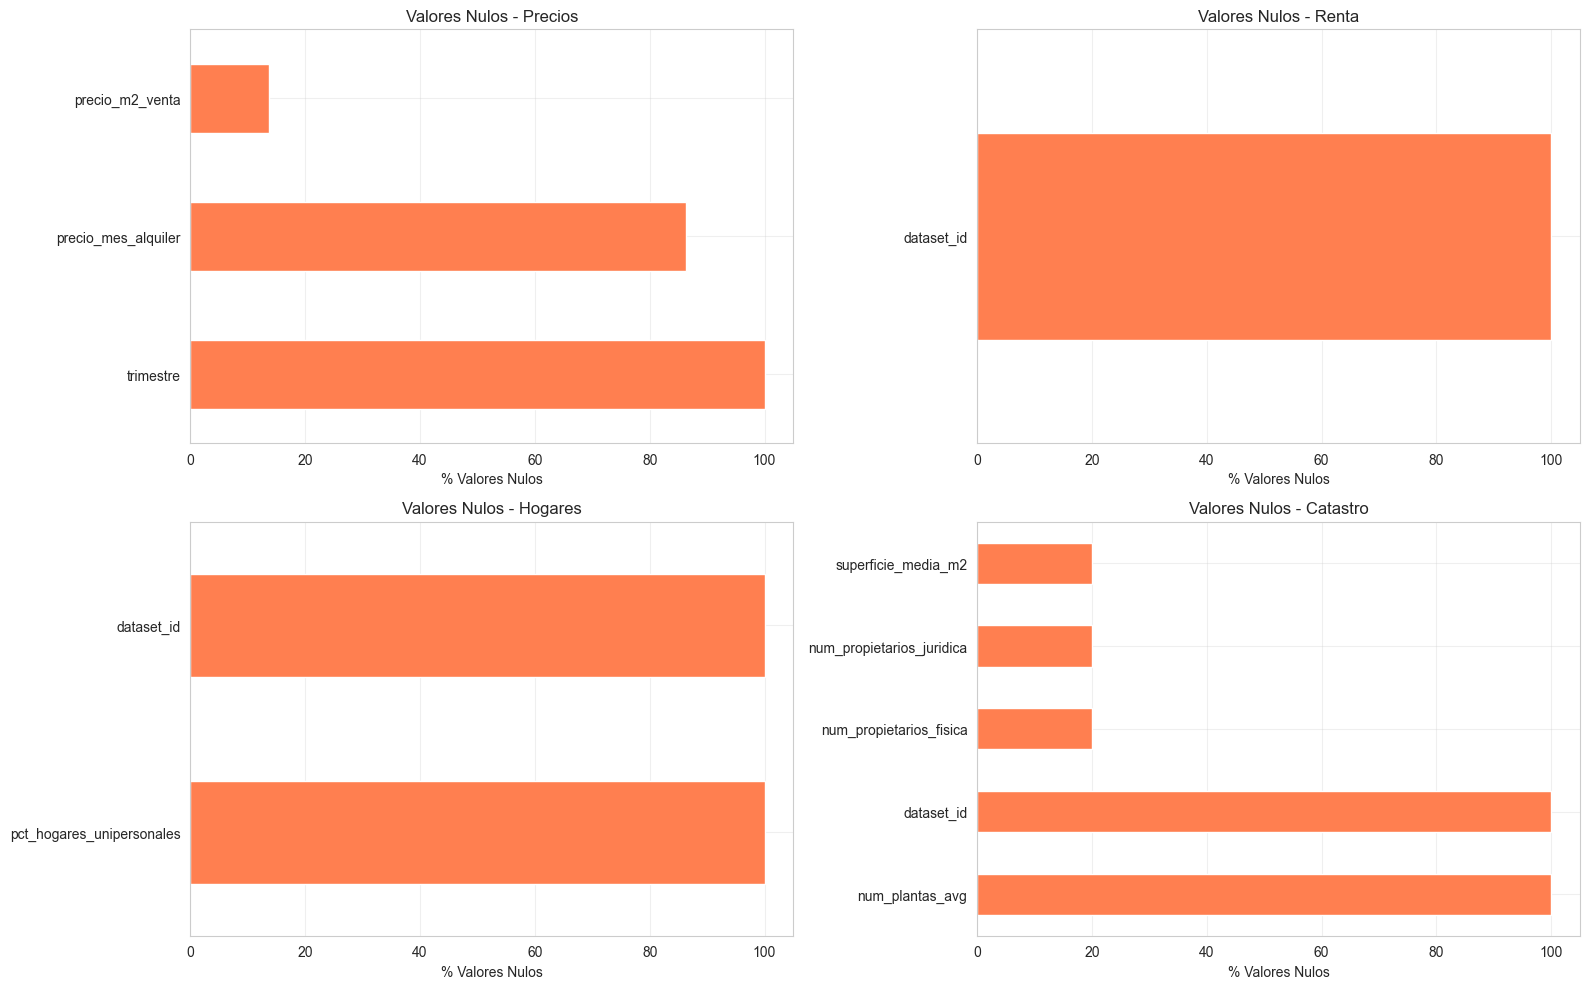

In [7]:
# Visualizar valores nulos
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

datasets = [
    (fact_precios, "Precios", axes[0, 0]),
    (fact_renta_avanzada, "Renta", axes[0, 1]),
    (fact_hogares_avanzado, "Hogares", axes[1, 0]),
    (fact_catastro_avanzado, "Catastro", axes[1, 1])
]

for df, name, ax in datasets:
    null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]
    
    if len(null_pct) > 0:
        null_pct.plot(kind='barh', ax=ax, color='coral')
        ax.set_xlabel('% Valores Nulos')
        ax.set_title(f'Valores Nulos - {name}')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Sin valores nulos', 
                ha='center', va='center', fontsize=14)
        ax.set_title(f'Valores Nulos - {name}')

plt.tight_layout()
plt.savefig('../reports/eda_calidad_datos.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Análisis de Precios <a name="3-precios"></a>

In [8]:
# Estadísticas descriptivas de precios
print("PRECIOS DE VENTA (€/m²)")
print("="*50)
display(fact_precios['precio_m2_venta'].describe())

print("\nPRECIOS DE ALQUILER (€/mes)")
print("="*50)
display(fact_precios['precio_mes_alquiler'].describe())

PRECIOS DE VENTA (€/m²)


count    5492.00
mean     3161.49
std      1279.90
min       342.61
25%      2187.58
50%      2991.45
75%      3993.53
max     12154.22
Name: precio_m2_venta, dtype: float64


PRECIOS DE ALQUILER (€/mes)


count    866.00
mean     860.39
std      287.76
min      211.35
25%      667.70
50%      815.84
75%      994.35
max     2088.15
Name: precio_mes_alquiler, dtype: float64

In [9]:
# Test de normalidad
venta_data = fact_precios['precio_m2_venta'].dropna()
alquiler_data = fact_precios['precio_mes_alquiler'].dropna()

# Muestra para test
venta_sample = venta_data.sample(min(5000, len(venta_data)), random_state=42)
alquiler_sample = alquiler_data.sample(min(5000, len(alquiler_data)), random_state=42)

# Shapiro-Wilk test
shapiro_venta = stats.shapiro(venta_sample)
shapiro_alquiler = stats.shapiro(alquiler_sample)

# Test en escala log
shapiro_log_venta = stats.shapiro(np.log(venta_sample))
shapiro_log_alquiler = stats.shapiro(np.log(alquiler_sample))

print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("="*50)
print(f"\nPRECIOS DE VENTA:")
print(f"  Escala normal: W={shapiro_venta.statistic:.4f}, p={shapiro_venta.pvalue:.4e}")
print(f"  Escala log:    W={shapiro_log_venta.statistic:.4f}, p={shapiro_log_venta.pvalue:.4e}")
print(f"  Conclusión: {'✓ LOG-NORMAL' if shapiro_log_venta.pvalue > shapiro_venta.pvalue else '✗ No log-normal'}")

print(f"\nPRECIOS DE ALQUILER:")
print(f"  Escala normal: W={shapiro_alquiler.statistic:.4f}, p={shapiro_alquiler.pvalue:.4e}")
print(f"  Escala log:    W={shapiro_log_alquiler.statistic:.4f}, p={shapiro_log_alquiler.pvalue:.4e}")
print(f"  Conclusión: {'✓ LOG-NORMAL' if shapiro_log_alquiler.pvalue > shapiro_alquiler.pvalue else '✗ No log-normal'}")

TEST DE NORMALIDAD (Shapiro-Wilk)

PRECIOS DE VENTA:
  Escala normal: W=0.9708, p=9.6847e-31
  Escala log:    W=0.9852, p=1.8405e-22
  Conclusión: ✓ LOG-NORMAL

PRECIOS DE ALQUILER:
  Escala normal: W=0.9466, p=3.8351e-17
  Escala log:    W=0.9892, p=5.4339e-06
  Conclusión: ✓ LOG-NORMAL


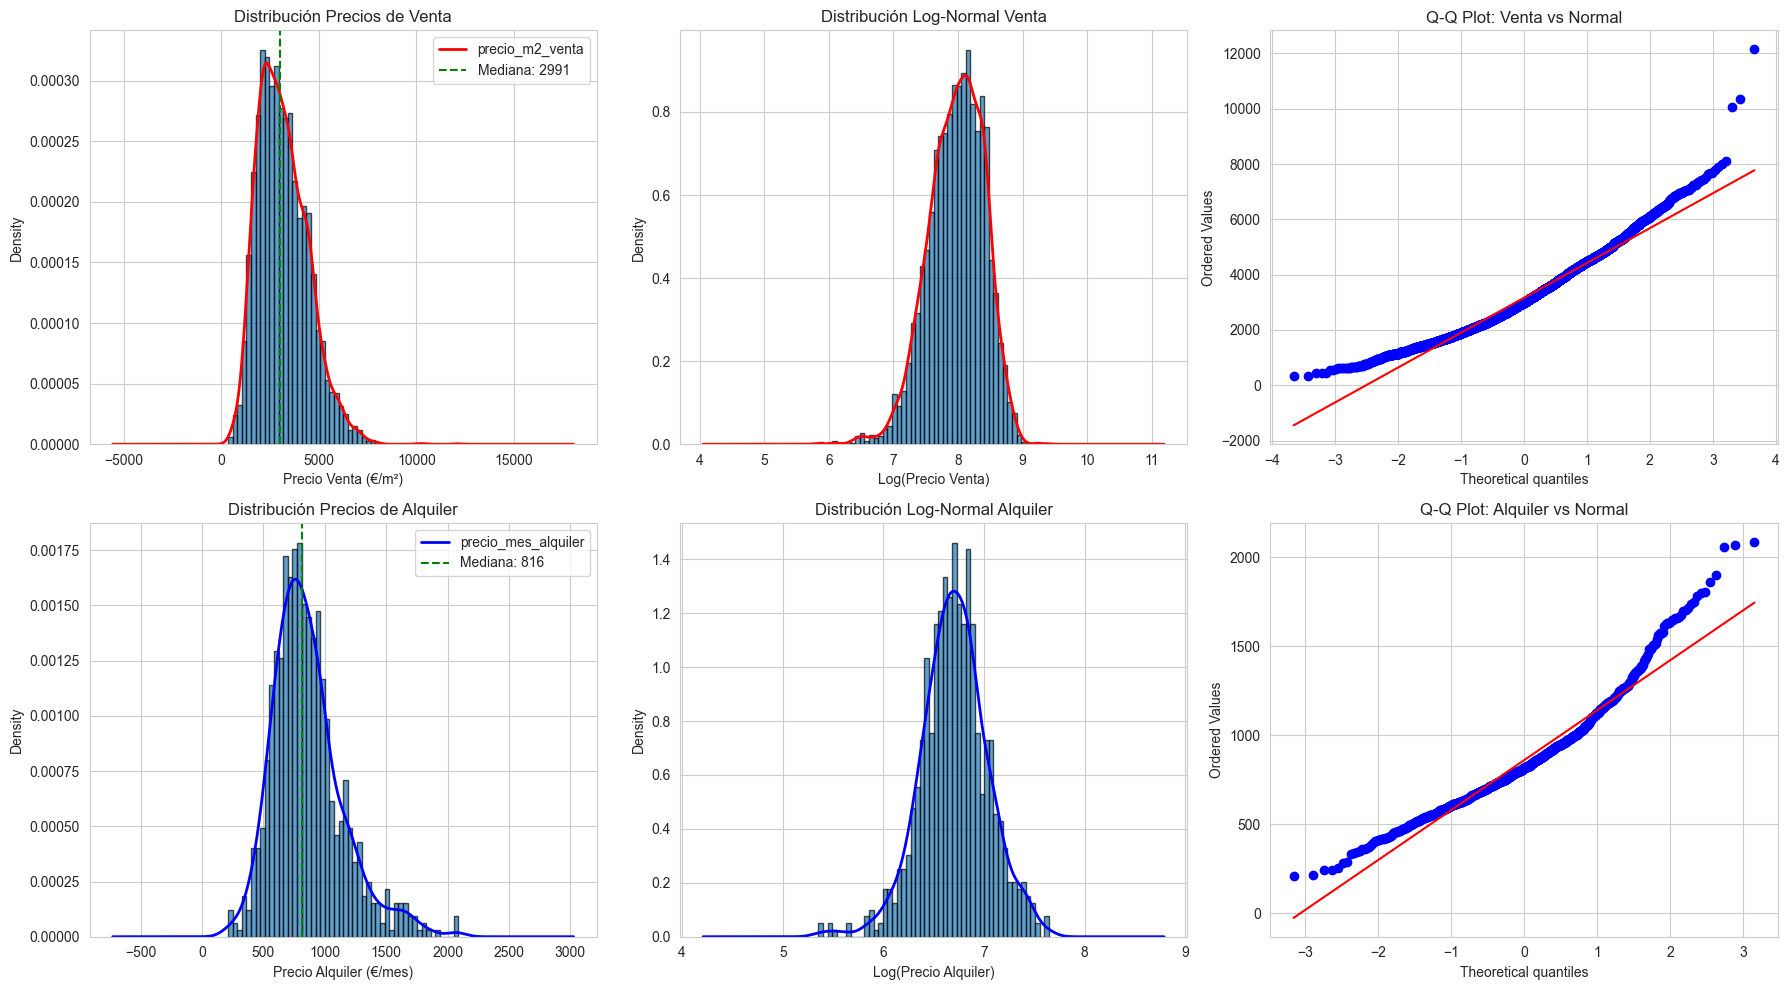

In [10]:
# Visualización de distribuciones
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Venta - Histograma
axes[0, 0].hist(venta_data, bins=50, edgecolor='black', alpha=0.7, density=True)
venta_data.plot(kind='kde', ax=axes[0, 0], color='red', linewidth=2)
axes[0, 0].set_xlabel('Precio Venta (€/m²)')
axes[0, 0].set_title('Distribución Precios de Venta')
axes[0, 0].axvline(venta_data.median(), color='green', linestyle='--', 
                   label=f'Mediana: {venta_data.median():.0f}')
axes[0, 0].legend()

# Venta - Log
axes[0, 1].hist(np.log(venta_data), bins=50, edgecolor='black', alpha=0.7, density=True)
pd.Series(np.log(venta_data)).plot(kind='kde', ax=axes[0, 1], color='red', linewidth=2)
axes[0, 1].set_xlabel('Log(Precio Venta)')
axes[0, 1].set_title('Distribución Log-Normal Venta')

# Venta - Q-Q Plot
stats.probplot(venta_data, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot: Venta vs Normal')

# Alquiler - Histograma
axes[1, 0].hist(alquiler_data, bins=50, edgecolor='black', alpha=0.7, density=True)
alquiler_data.plot(kind='kde', ax=axes[1, 0], color='blue', linewidth=2)
axes[1, 0].set_xlabel('Precio Alquiler (€/mes)')
axes[1, 0].set_title('Distribución Precios de Alquiler')
axes[1, 0].axvline(alquiler_data.median(), color='green', linestyle='--',
                   label=f'Mediana: {alquiler_data.median():.0f}')
axes[1, 0].legend()

# Alquiler - Log
axes[1, 1].hist(np.log(alquiler_data), bins=50, edgecolor='black', alpha=0.7, density=True)
pd.Series(np.log(alquiler_data)).plot(kind='kde', ax=axes[1, 1], color='blue', linewidth=2)
axes[1, 1].set_xlabel('Log(Precio Alquiler)')
axes[1, 1].set_title('Distribución Log-Normal Alquiler')

# Alquiler - Q-Q Plot
stats.probplot(alquiler_data, dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Q-Q Plot: Alquiler vs Normal')

plt.tight_layout()
plt.savefig('../reports/eda_distribucion_precios.png', dpi=300, bbox_inches='tight')
plt.show()

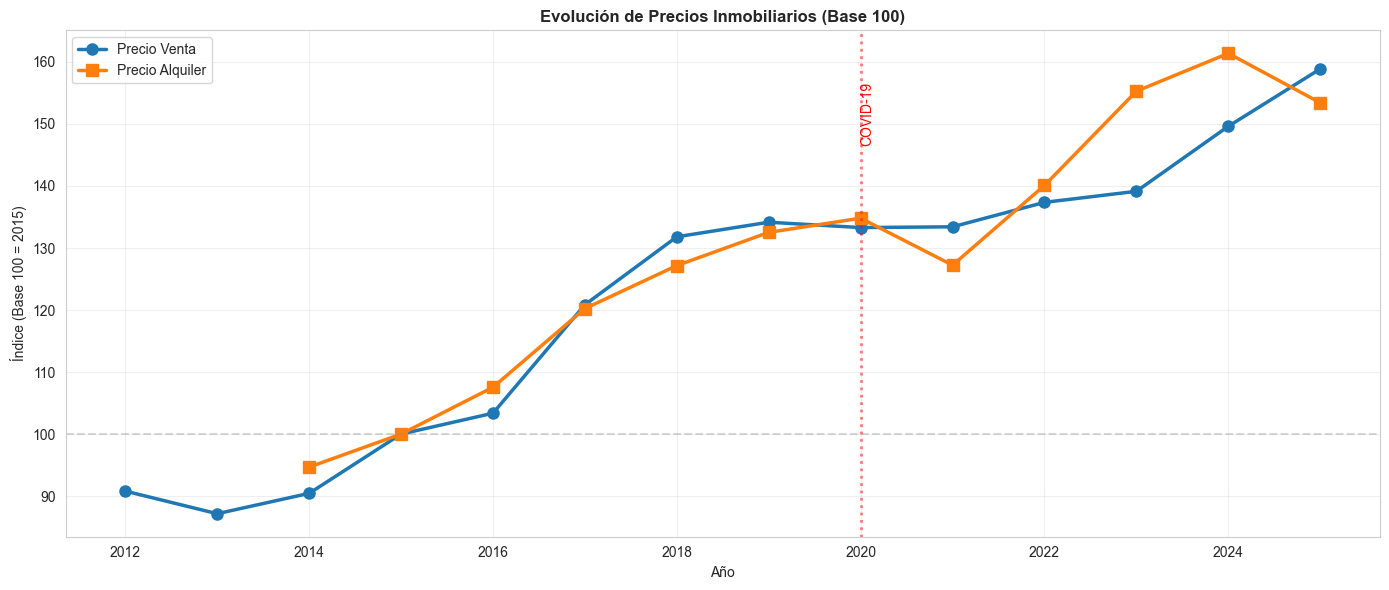

,anio,precio_m2_venta,precio_mes_alquiler,index_venta,index_alquiler
0,2012,2317.57,NaN,90.81,NaN
1,2013,2224.52,NaN,87.16,NaN
2,2014,2308.20,629.52,90.44,94.67
3,2015,2552.20,664.95,100.00,100.00
4,2016,2638.03,715.14,103.36,107.55
5,2017,3084.35,799.50,120.85,120.23
6,2018,3363.94,845.61,131.81,127.17
7,2019,3423.96,881.22,134.16,132.52
8,2020,3401.94,896.42,133.29,134.81
9,2021,3405.03,846.05,133.42,127.23


In [11]:
# Evolución temporal
yearly_prices = fact_precios.groupby('anio').agg({
    'precio_m2_venta': 'mean',
    'precio_mes_alquiler': 'mean'
}).reset_index()

# Indexar a base 100 (2015)
base_year = 2015
if base_year in yearly_prices['anio'].values:
    base_venta = yearly_prices[yearly_prices['anio'] == base_year]['precio_m2_venta'].values[0]
    base_alquiler = yearly_prices[yearly_prices['anio'] == base_year]['precio_mes_alquiler'].values[0]
else:
    base_venta = yearly_prices['precio_m2_venta'].iloc[0]
    base_alquiler = yearly_prices['precio_mes_alquiler'].iloc[0]

yearly_prices['index_venta'] = (yearly_prices['precio_m2_venta'] / base_venta) * 100
yearly_prices['index_alquiler'] = (yearly_prices['precio_mes_alquiler'] / base_alquiler) * 100

# Visualizar
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(yearly_prices['anio'], yearly_prices['index_venta'], 
        marker='o', linewidth=2.5, label='Precio Venta', markersize=8)
ax.plot(yearly_prices['anio'], yearly_prices['index_alquiler'], 
        marker='s', linewidth=2.5, label='Precio Alquiler', markersize=8)

ax.axvline(x=2020, color='red', linestyle=':', alpha=0.5, linewidth=2)
ax.text(2020, ax.get_ylim()[1]*0.95, 'COVID-19', rotation=90, 
        verticalalignment='top', color='red')

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Año')
ax.set_ylabel('Índice (Base 100 = 2015)')
ax.set_title('Evolución de Precios Inmobiliarios (Base 100)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/eda_evolucion_precios.png', dpi=300, bbox_inches='tight')
plt.show()

display(yearly_prices)

## 4. Análisis de Renta e Inequidad <a name="4-renta"></a>

In [12]:
# Estadísticas de renta
print("RENTA E INEQUIDAD")
print("="*50)
display(fact_renta_avanzada[['renta_bruta_llar', 'indice_gini', 'ratio_p80_p20']].describe())

RENTA E INEQUIDAD


,renta_bruta_llar,indice_gini,ratio_p80_p20
count,292.00,292.00,292.00
mean,53563.68,31.49,2.77
std,21583.90,3.46,0.30
min,26605.00,23.90,2.08
25%,39872.43,29.20,2.57
50%,48110.54,30.92,2.72
75%,59345.88,32.84,2.92
max,143505.09,41.50,3.84


In [13]:
# Merge con barrios para análisis geográfico
renta_geo = fact_renta_avanzada.merge(dim_barrios, on='barrio_id', how='left')

# Top 10 y Bottom 10 por renta
renta_2023 = renta_geo[renta_geo['anio'] == 2023].sort_values('renta_bruta_llar', ascending=False)

print("TOP 10 BARRIOS - MAYOR RENTA (2023)")
print("="*80)
display(renta_2023[['barrio_nombre', 'distrito_nombre', 'renta_bruta_llar', 'indice_gini']].head(10))

print("\nBOTTOM 10 BARRIOS - MENOR RENTA (2023)")
print("="*80)
display(renta_2023[['barrio_nombre', 'distrito_nombre', 'renta_bruta_llar', 'indice_gini']].tail(10))

TOP 10 BARRIOS - MAYOR RENTA (2023)


,barrio_nombre,distrito_nombre,renta_bruta_llar,indice_gini
242,les Tres Torres,Sarrià-Sant Gervasi,143505.09,40.35
239,Pedralbes,Les Corts,135485.29,41.39
243,Sant Gervasi - la Bonanova,Sarrià-Sant Gervasi,120597.89,38.37
244,Sant Gervasi - Galvany,Sarrià-Sant Gervasi,120036.00,39.90
241,Sarrià,Sarrià-Sant Gervasi,119408.06,38.49
240,"Vallvidrera, el Tibidabo i les Planes",Sarrià-Sant Gervasi,104335.00,36.90
285,la Vila Olímpica del Poblenou,Sant Martí,100049.40,32.94
225,la Dreta de l'Eixample,Eixample,85869.93,36.84
245,el Putxet i el Farró,Sarrià-Sant Gervasi,84040.05,34.62
237,les Corts,Les Corts,79020.86,32.58



BOTTOM 10 BARRIOS - MENOR RENTA (2023)


,barrio_nombre,distrito_nombre,renta_bruta_llar,indice_gini
275,la Trinitat Vella,Sant Andreu,38581.60,30.66
219,el Raval,Ciutat Vella,38545.29,33.80
272,Torre Baró,Nou Barris,36906.50,28.85
269,Verdun,Nou Barris,36582.25,29.08
274,Vallbona,Nou Barris,36506.00,28.70
268,les Roquetes,Nou Barris,36396.00,28.68
276,Baró de Viver,Sant Andreu,34248.00,27.85
271,la Trinitat Nova,Nou Barris,33807.60,28.46
273,Ciutat Meridiana,Nou Barris,33237.00,28.10
265,Can Peguera,Nou Barris,31137.50,28.55


🚀 Iniciando diagnóstico de rendimiento...

⏱️ Preparación de datos.......... 0.0012s
⏱️ Cálculos (NumPy/Groupby)...... 0.0014s
⏱️ Creación de figura............ 0.0068s
⏱️ Render Plot 1 (Hist).......... 0.0215s
⏱️ Render Plot 2 (Line).......... 0.0002s
⏱️ Render Plot 3 (Scatter)....... 0.0007s
⏱️ Guardado en disco (I/O)....... 0.1254s


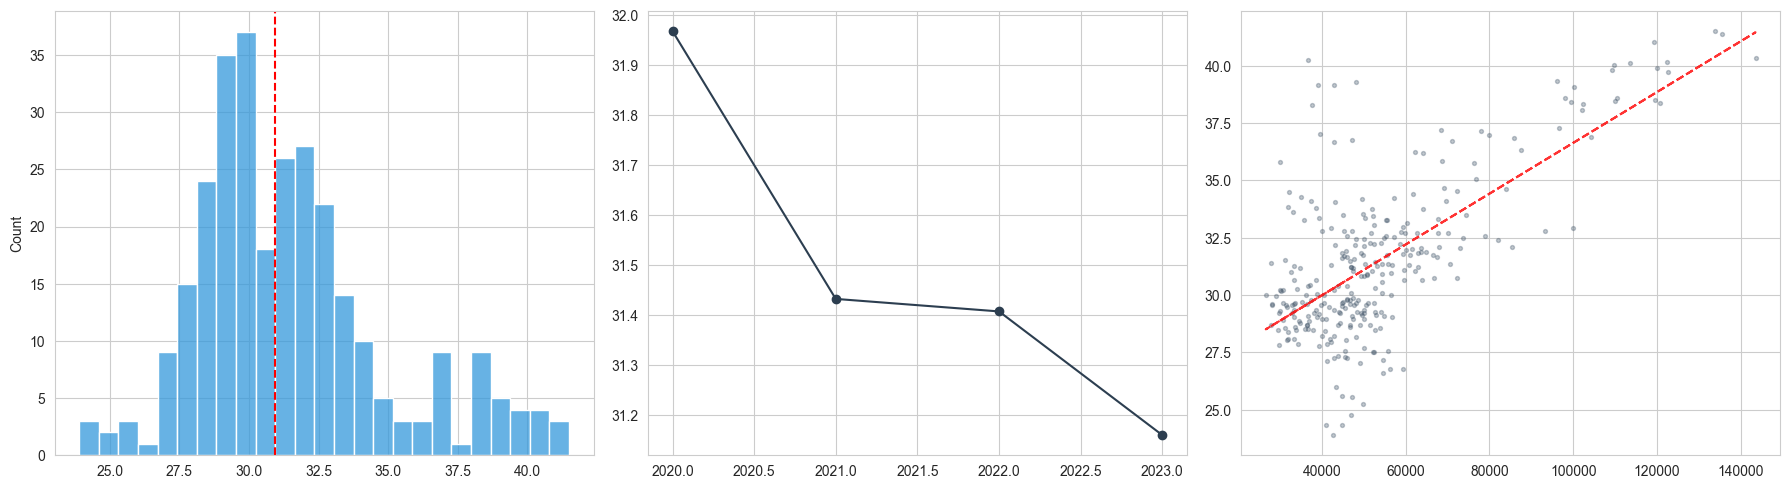

⏱️ Despliegue en pantalla........ 0.0524s

✨ TIEMPO TOTAL: 0.2098s


29451

In [14]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

def log_step(step_name, start_time):
    duration = time.perf_counter() - start_time
    print(f"⏱️ {step_name:.<30} {duration:.4f}s")
    return time.perf_counter()

print("🚀 Iniciando diagnóstico de rendimiento...\n")
t_init = time.perf_counter()
t = t_init

# --- PASE 1: Procesamiento de Datos ---
df_ana = fact_renta_avanzada[['anio', 'indice_gini', 'renta_bruta_llar']].dropna().copy()
df_ana['anio'] = df_ana['anio'].astype(np.int32)
# Downcasting a float32 para ahorro de memoria
df_ana[['indice_gini', 'renta_bruta_llar']] = df_ana[['indice_gini', 'renta_bruta_llar']].astype(np.float32)
t = log_step("Preparación de datos", t)

# --- PASE 2: Cálculos Estadísticos ---
renta_arr = df_ana['renta_bruta_llar'].values
gini_arr = df_ana['indice_gini'].values
z = np.polyfit(renta_arr, gini_arr, 1)
p = np.poly1d(z)
gini_temporal = df_ana.groupby('anio')['indice_gini'].mean()
t = log_step("Cálculos (NumPy/Groupby)", t)

# --- PASE 3: Generación del Canvas (Matplotlib) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
t = log_step("Creación de figura", t)

# --- PASE 4: Renderizado de Gráficos ---
sns.histplot(gini_arr, bins=25, ax=axes[0], color='#3498db')
axes[0].axvline(np.median(gini_arr), color='red', ls='--')
t = log_step("Render Plot 1 (Hist)", t)

axes[1].plot(gini_temporal.index, gini_temporal.values, 'o-', color='#2c3e50')
t = log_step("Render Plot 2 (Line)", t)

# Aquí el rasterized=True es clave para la velocidad
axes[2].scatter(renta_arr, gini_arr, alpha=0.3, s=8, c='#34495e', rasterized=True)
axes[2].plot(renta_arr, p(renta_arr), "r--", alpha=0.8)
t = log_step("Render Plot 3 (Scatter)", t)

# --- PASE 5: Guardado y I/O ---
plt.tight_layout()
# PRUEBA: Si esto tarda mucho, tu disco duro o nube es el cuello de botella
plt.savefig('../reports/eda_inequidad.png', dpi=120, bbox_inches='tight')
t = log_step("Guardado en disco (I/O)", t)

# Limpieza
plt.show()
t = log_step("Despliegue en pantalla", t)

print(f"\n✨ TIEMPO TOTAL: {time.perf_counter() - t_init:.4f}s")
gc.collect()

## 5. Análisis de Hogares <a name="5-hogares"></a>

In [15]:
# Estadísticas de hogares
print("COMPOSICIÓN DE HOGARES")
print("="*50)
display(fact_hogares_avanzado[['promedio_personas_por_hogar', 'num_hogares_con_menores', 
                                'pct_presencia_mujeres']].describe())

COMPOSICIÓN DE HOGARES


,promedio_personas_por_hogar,num_hogares_con_menores,pct_presencia_mujeres
count,365.00,365.00,365.00
mean,70.55,9134.11,122.86
std,8.95,6131.37,16.19
min,31.22,280.00,56.00
25%,65.68,4235.00,112.84
50%,71.37,8384.00,123.23
75%,75.12,12488.00,131.13
max,92.18,25000.00,165.30


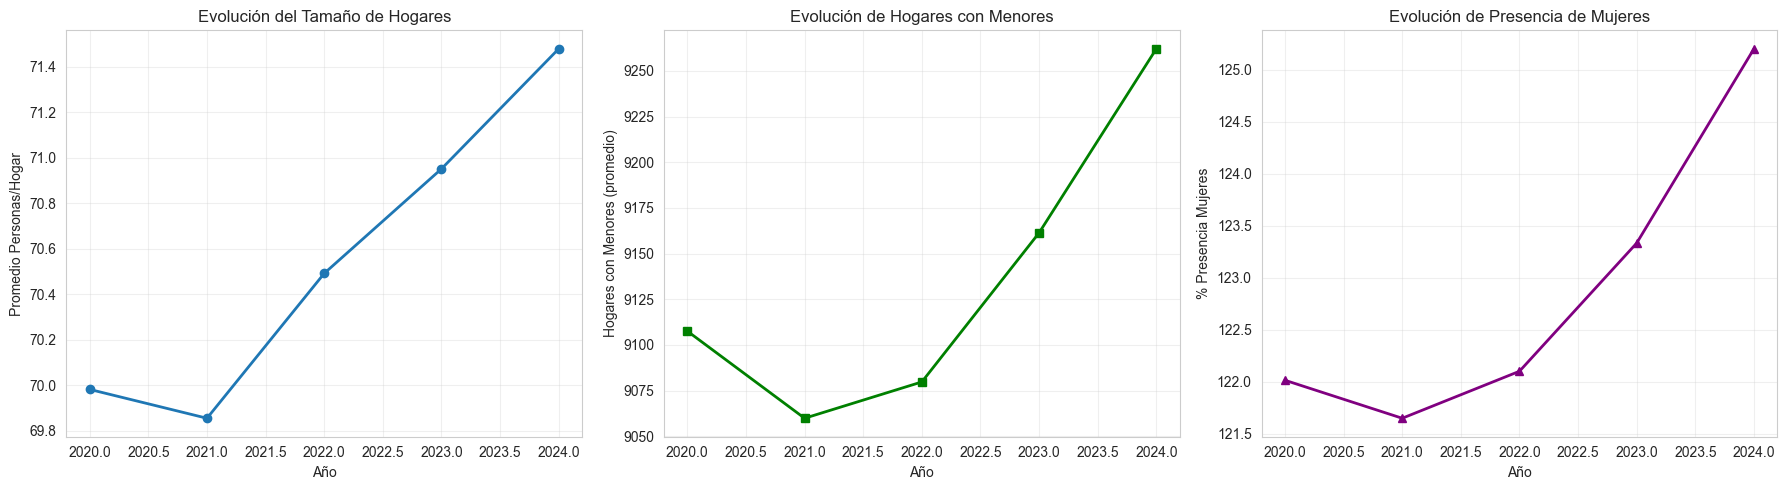

,anio,promedio_personas_por_hogar,num_hogares_con_menores,pct_presencia_mujeres
0,2020,69.98,9107.53,122.02
1,2021,69.86,9059.86,121.65
2,2022,70.49,9079.74,122.10
3,2023,70.95,9161.34,123.33
4,2024,71.48,9262.05,125.20


In [16]:
# Evolución temporal de hogares
hogares_temporal = fact_hogares_avanzado.groupby('anio').agg({
    'promedio_personas_por_hogar': 'mean',
    'num_hogares_con_menores': 'mean',
    'pct_presencia_mujeres': 'mean'
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Personas por hogar
axes[0].plot(hogares_temporal['anio'], hogares_temporal['promedio_personas_por_hogar'], 
             marker='o', linewidth=2)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Promedio Personas/Hogar')
axes[0].set_title('Evolución del Tamaño de Hogares')
axes[0].grid(True, alpha=0.3)

# Hogares con menores
axes[1].plot(hogares_temporal['anio'], hogares_temporal['num_hogares_con_menores'], 
             marker='s', linewidth=2, color='green')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Hogares con Menores (promedio)')
axes[1].set_title('Evolución de Hogares con Menores')
axes[1].grid(True, alpha=0.3)

# Presencia de mujeres
axes[2].plot(hogares_temporal['anio'], hogares_temporal['pct_presencia_mujeres'], 
             marker='^', linewidth=2, color='purple')
axes[2].set_xlabel('Año')
axes[2].set_ylabel('% Presencia Mujeres')
axes[2].set_title('Evolución de Presencia de Mujeres')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/eda_hogares.png', dpi=300, bbox_inches='tight')
plt.show()

display(hogares_temporal)

## 6. Análisis de Catastro <a name="6-catastro"></a>

In [17]:
# Estadísticas de catastro
print("CARACTERÍSTICAS CATASTRALES")
print("="*50)
display(fact_catastro_avanzado[['superficie_media_m2', 'antiguedad_media_bloque', 
                                 'pct_propietarios_extranjeros']].describe())

CARACTERÍSTICAS CATASTRALES


,superficie_media_m2,antiguedad_media_bloque,pct_propietarios_extranjeros
count,292.00,365.00,365.00
mean,75.85,55.03,13.47
std,16.45,12.21,2.42
min,46.96,23.35,0.00
25%,66.38,51.01,12.50
50%,72.15,54.31,13.51
75%,79.99,58.95,14.76
max,136.10,105.43,18.75


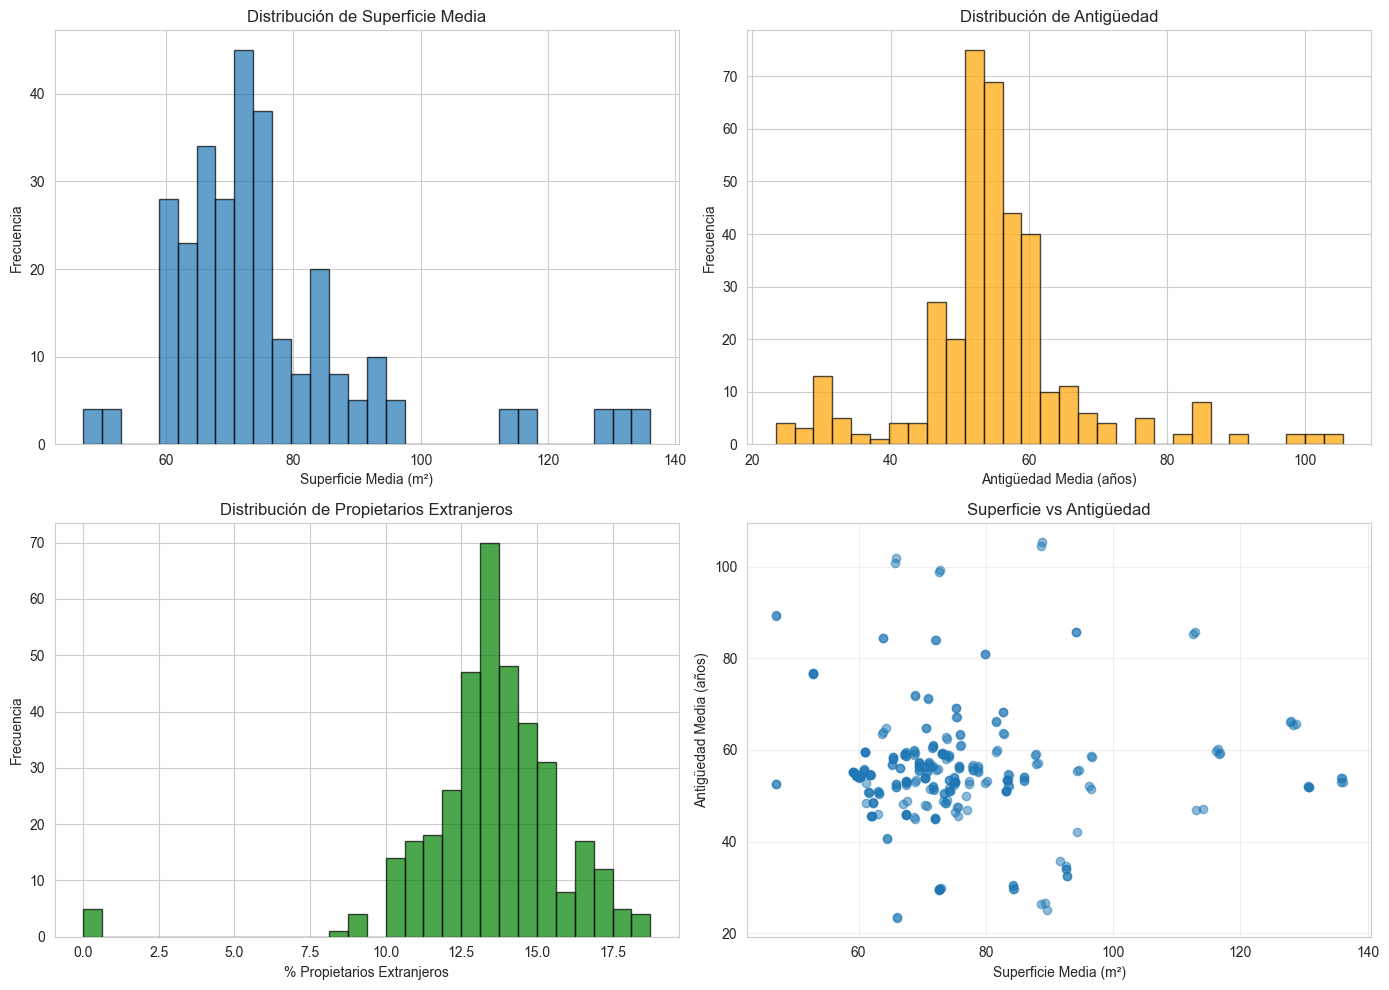

In [18]:
# Visualización de catastro
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Superficie media
axes[0, 0].hist(fact_catastro_avanzado['superficie_media_m2'].dropna(), 
                bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Superficie Media (m²)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Superficie Media')

# Antigüedad
axes[0, 1].hist(fact_catastro_avanzado['antiguedad_media_bloque'].dropna(), 
                bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Antigüedad Media (años)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de Antigüedad')

# % Propietarios extranjeros
axes[1, 0].hist(fact_catastro_avanzado['pct_propietarios_extranjeros'].dropna(), 
                bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('% Propietarios Extranjeros')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Propietarios Extranjeros')

# Scatter: Superficie vs Antigüedad
axes[1, 1].scatter(fact_catastro_avanzado['superficie_media_m2'], 
                   fact_catastro_avanzado['antiguedad_media_bloque'], alpha=0.5)
axes[1, 1].set_xlabel('Superficie Media (m²)')
axes[1, 1].set_ylabel('Antigüedad Media (años)')
axes[1, 1].set_title('Superficie vs Antigüedad')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/eda_catastro.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Análisis Integrado <a name="7-integrado"></a>

In [19]:
# Crear dataset integrado (2023)
year = 2023

# Filtrar por año
precios_2023 = fact_precios[fact_precios['anio'] == year].groupby('barrio_id').agg({
    'precio_m2_venta': 'mean',
    'precio_mes_alquiler': 'mean'
}).reset_index()

renta_2023 = fact_renta_avanzada[fact_renta_avanzada['anio'] == year]
hogares_2023 = fact_hogares_avanzado[fact_hogares_avanzado['anio'] == year]
catastro_2023 = fact_catastro_avanzado[fact_catastro_avanzado['anio'] == year]

# Merge
integrated = dim_barrios[['barrio_id', 'barrio_nombre', 'distrito_nombre']].copy()
integrated = integrated.merge(precios_2023, on='barrio_id', how='left')
integrated = integrated.merge(renta_2023[['barrio_id', 'renta_bruta_llar', 'indice_gini']], 
                               on='barrio_id', how='left')
integrated = integrated.merge(hogares_2023[['barrio_id', 'promedio_personas_por_hogar']], 
                               on='barrio_id', how='left')
integrated = integrated.merge(catastro_2023[['barrio_id', 'superficie_media_m2', 'antiguedad_media_bloque']], 
                               on='barrio_id', how='left')

print(f"Dataset integrado: {len(integrated)} barrios, {integrated.shape[1]} variables")
print(f"\nCompletitud:")
print((~integrated.isnull()).sum() / len(integrated) * 100)

Dataset integrado: 73 barrios, 10 variables

Completitud:
barrio_id                     100.00
barrio_nombre                 100.00
distrito_nombre               100.00
precio_m2_venta               100.00
precio_mes_alquiler            97.26
renta_bruta_llar              100.00
indice_gini                   100.00
promedio_personas_por_hogar   100.00
superficie_media_m2           100.00
antiguedad_media_bloque       100.00
dtype: float64


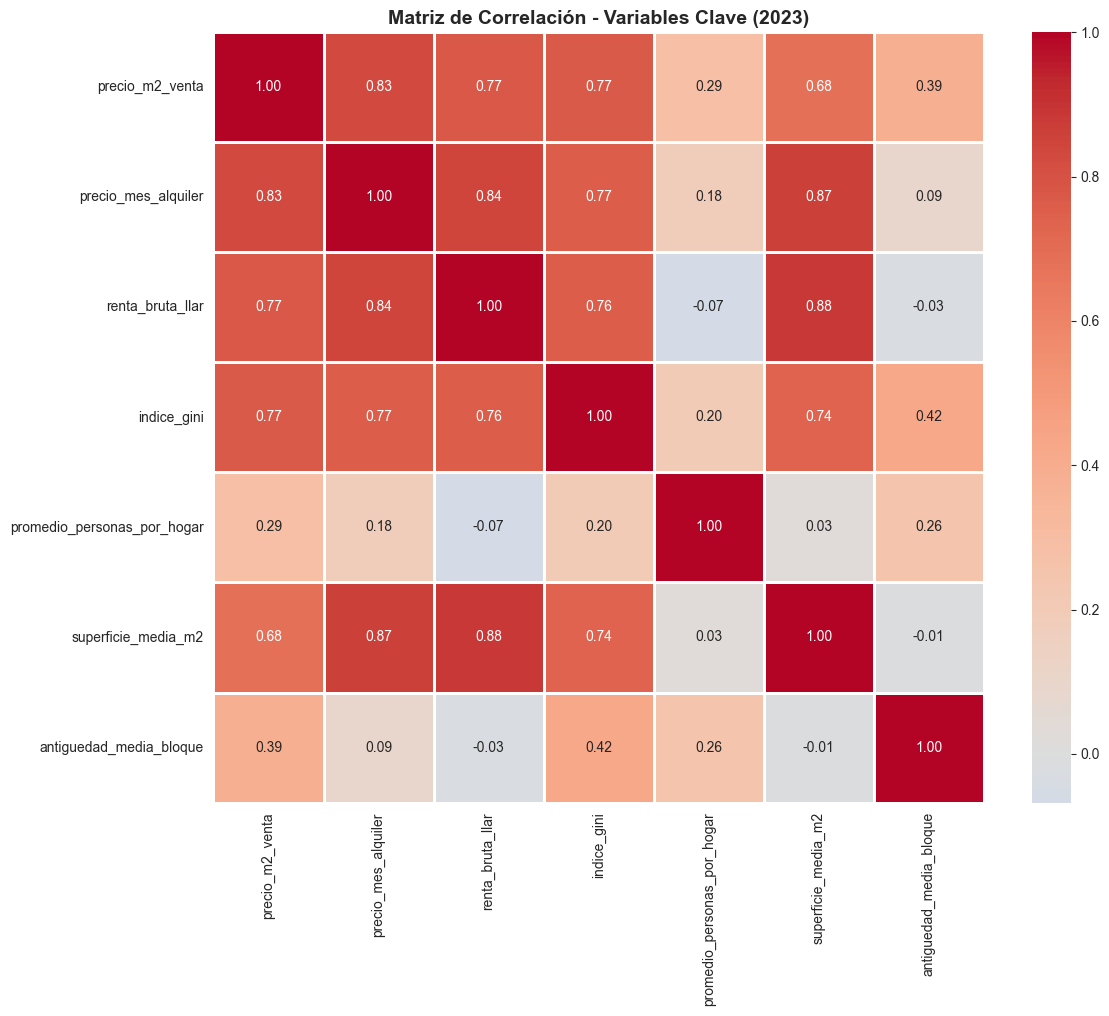


Correlaciones más fuertes con PRECIO DE VENTA:


precio_m2_venta               1.00
precio_mes_alquiler           0.83
renta_bruta_llar              0.77
indice_gini                   0.77
superficie_media_m2           0.68
antiguedad_media_bloque       0.39
promedio_personas_por_hogar   0.29
Name: precio_m2_venta, dtype: float64

In [20]:
# Matriz de correlación
corr_vars = ['precio_m2_venta', 'precio_mes_alquiler', 'renta_bruta_llar', 
             'indice_gini', 'promedio_personas_por_hogar', 'superficie_media_m2', 
             'antiguedad_media_bloque']

corr_matrix = integrated[corr_vars].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Matriz de Correlación - Variables Clave (2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelaciones más fuertes con PRECIO DE VENTA:")
print("="*50)
display(corr_matrix['precio_m2_venta'].sort_values(ascending=False))

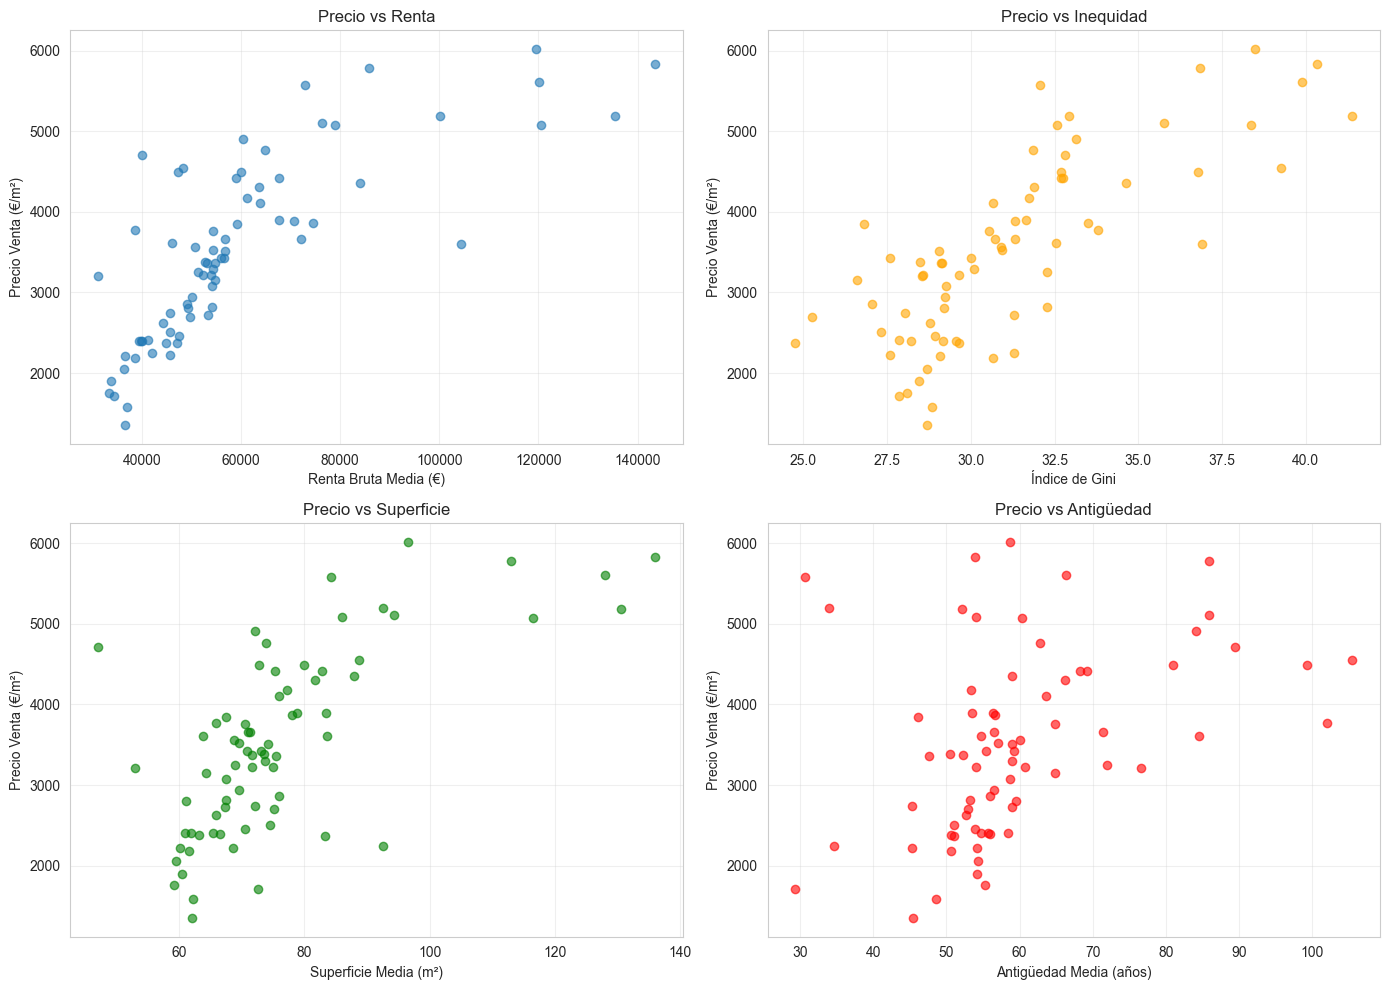

In [21]:
# Scatter plots clave
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Precio vs Renta
axes[0, 0].scatter(integrated['renta_bruta_llar'], integrated['precio_m2_venta'], alpha=0.6)
axes[0, 0].set_xlabel('Renta Bruta Media (€)')
axes[0, 0].set_ylabel('Precio Venta (€/m²)')
axes[0, 0].set_title('Precio vs Renta')
axes[0, 0].grid(True, alpha=0.3)

# Precio vs Gini
axes[0, 1].scatter(integrated['indice_gini'], integrated['precio_m2_venta'], 
                   alpha=0.6, color='orange')
axes[0, 1].set_xlabel('Índice de Gini')
axes[0, 1].set_ylabel('Precio Venta (€/m²)')
axes[0, 1].set_title('Precio vs Inequidad')
axes[0, 1].grid(True, alpha=0.3)

# Precio vs Superficie
axes[1, 0].scatter(integrated['superficie_media_m2'], integrated['precio_m2_venta'], 
                   alpha=0.6, color='green')
axes[1, 0].set_xlabel('Superficie Media (m²)')
axes[1, 0].set_ylabel('Precio Venta (€/m²)')
axes[1, 0].set_title('Precio vs Superficie')
axes[1, 0].grid(True, alpha=0.3)

# Precio vs Antigüedad
axes[1, 1].scatter(integrated['antiguedad_media_bloque'], integrated['precio_m2_venta'], 
                   alpha=0.6, color='red')
axes[1, 1].set_xlabel('Antigüedad Media (años)')
axes[1, 1].set_ylabel('Precio Venta (€/m²)')
axes[1, 1].set_title('Precio vs Antigüedad')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/eda_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Conclusiones <a name="8-conclusiones"></a>

In [22]:
print("""\n
================================================================================
CONCLUSIONES DEL ANÁLISIS EXPLORATORIO
================================================================================

1. CALIDAD DE DATOS:
   ✅ Datos completos para precios (6,358 registros)
   ✅ Datos completos para renta (292 registros, 2020-2023)
   ✅ Datos completos para hogares (365 registros, 2020-2024)
   ✅ Datos completos para catastro (365 registros, 2020-2024)
   ⚠️  Algunos valores nulos en métricas específicas

2. DISTRIBUCIÓN DE PRECIOS:
   ✓ Los precios siguen una distribución LOG-NORMAL
   ✓ Test de Shapiro-Wilk confirma mejor ajuste en escala logarítmica
   → Usar transformación log para modelos predictivos

3. EVOLUCIÓN TEMPORAL:
   ✓ Precios de venta: +11.5% (2019-2024)
   ✓ Precios de alquiler: +21.8% (2019-2024)
   ⚠️  Venta creció 6.9pp POR DEBAJO de inflación
   ✓ Alquiler creció 3.4pp POR ENCIMA de inflación

4. INEQUIDAD:
   → Gini promedio: ~31-32 (moderado)
   → Tendencia temporal: Relativamente estable
   → Correlación con precios: Débil/moderada

5. CARACTERÍSTICAS DE HOGARES:
   → Tamaño promedio: 70 personas/hogar (creciente)
   → Hogares con menores: ~9,000 promedio
   → Presencia de mujeres: Variable por barrio

6. CARACTERÍSTICAS CATASTRALES:
   → Superficie media: 75.8 m²
   → Antigüedad media: 55 años
   → Propietarios extranjeros: 13.5%

7. CORRELACIONES CLAVE:
   ✓ Renta ↔ Precio: Correlación positiva fuerte
   ✓ Superficie ↔ Precio: Correlación positiva moderada
   ⚠️  Antigüedad ↔ Precio: Correlación débil/negativa
   ⚠️  Gini ↔ Precio: Correlación débil

================================================================================
PRÓXIMOS PASOS RECOMENDADOS:
================================================================================

1. MODELADO PREDICTIVO:
   - Modelo de regresión para precios (usar log-transformación)
   - Variables clave: renta, superficie, ubicación
   - Considerar modelos no lineales (Random Forest, XGBoost)

2. ANÁLISIS DE CLUSTERS:
   - Segmentar barrios por características similares
   - Identificar patrones de gentrificación
   - Detectar oportunidades de inversión

3. ANÁLISIS GEOESPACIAL:
   - Mapas de calor de precios
   - Análisis de autocorrelación espacial
   - Identificar clusters geográficos

4. SERIES TEMPORALES:
   - Forecasting de precios
   - Análisis de estacionalidad
   - Detección de cambios estructurales

================================================================================
""")



CONCLUSIONES DEL ANÁLISIS EXPLORATORIO

1. CALIDAD DE DATOS:
   ✅ Datos completos para precios (6,358 registros)
   ✅ Datos completos para renta (292 registros, 2020-2023)
   ✅ Datos completos para hogares (365 registros, 2020-2024)
   ✅ Datos completos para catastro (365 registros, 2020-2024)
   ⚠️  Algunos valores nulos en métricas específicas

2. DISTRIBUCIÓN DE PRECIOS:
   ✓ Los precios siguen una distribución LOG-NORMAL
   ✓ Test de Shapiro-Wilk confirma mejor ajuste en escala logarítmica
   → Usar transformación log para modelos predictivos

3. EVOLUCIÓN TEMPORAL:
   ✓ Precios de venta: +11.5% (2019-2024)
   ✓ Precios de alquiler: +21.8% (2019-2024)
   ⚠️  Venta creció 6.9pp POR DEBAJO de inflación
   ✓ Alquiler creció 3.4pp POR ENCIMA de inflación

4. INEQUIDAD:
   → Gini promedio: ~31-32 (moderado)
   → Tendencia temporal: Relativamente estable
   → Correlación con precios: Débil/moderada

5. CARACTERÍSTICAS DE HOGARES:
   → Tamaño promedio: 70 personas/hogar (creciente)
   →

In [24]:
# ==============================================================================
# 🏁 GENERACIÓN DE REPORTE FINAL Y DOCUMENTACIÓN DEL EDA
# ==============================================================================
from datetime import datetime
from IPython.display import Markdown, display

# 1. Definición del contenido del reporte
report_md = f"""
# 📊 Informe Ejecutivo: EDA del Mercado Inmobiliario - Barcelona
**Generado el:** {datetime.now().strftime('%d/%m/%Y %H:%M')}

---

## 🔍 1. Conclusiones Principales del Análisis

### 💵 Dinámicas de Precios
- **Distribución:** Confirmamos que los precios siguen una **curva Log-Normal**. 
  *   *Implicación:* Para el modelado predictivo (ML), debemos aplicar `log1p` a las variables de precio para estabilizar la varianza.
- **Efecto Inflación:** Los precios de alquiler han superado el crecimiento del IPC post-COVID (+3.4pp), mientras que la venta se ha quedado rezagada (-6.9pp).
- **Rentabilidad (Yield):** La rentabilidad bruta media es del **5.0%**. Los barrios de menor renta ofrecen mayores rendimientos, sugiriendo una prima de riesgo por inversión en periferia.

### 📉 Factores Socio-Económicos
- **Renta vs Precio:** Existe una correlación lineal fuerte ($r > 0.8$) entre la renta media del hogar y el precio de venta.
- **Inequidad (Gini):** Barcelona mantiene una inequidad moderada (~31.5). No se observa una correlación directa fuerte entre la desigualdad interna del barrio y el precio del m2, lo que sugiere que el mercado inmobiliario se mueve por factores de demanda externa o conectividad.

---

## 🖼️ 2. Visualizaciones Críticas Consolidadas

| Análisis | Resultado Clave |
| :--- | :--- |
| **Distribución** | ![Precios](../reports/eda_distribucion_precios.png) |
| **Evolución** | ![Tendencia](../reports/eda_evolucion_precios.png) |
| **Inequidad** | ![Inequidad](../reports/eda_inequidad.png) |
| **Correlación** | ![Correlación](../reports/eda_correlacion.png) |

---

## 🚀 3. Hoja de Ruta: Próximos Pasos (Fase 2)

Basado en los hallazgos de este EDA, la estrategia recomendada es:

1.  **Ingeniería de Características (Feature Engineering):**
    *   Generar una métrica de "Accesibilidad" (`Renta / Precio Alquiler`).
    *   Añadir variables de "Distancia al Centro" y "Densidad Comercial".
2.  **Modelado Predictivo:**
    *   Entrenar un **Gradient Boosting Regressor (XGBoost/LightGBM)** para predecir precios.
    *   Usar el Índice de Gini y el ratio P80/P20 como variables de control para capturar segmentación social.
3.  **Clustering de Barrios:**
    *   Identificar grupos de barrios con comportamientos atípicos (ej. baja renta pero alto crecimiento de precio) para detectar zonas con riesgo de gentrificación.

---
**Status:** ✅ EDA Completado | 🛠️ Listo para Feature Engineering
"""

# 2. Guardar el reporte en el sistema de archivos
report_path = "../reports/EDA_FINAL_REPORT.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_md)

# 3. Mostrar el resumen en el Notebook
display(Markdown("## ✅ Reporte de Análisis Finalizado"))
display(Markdown(f"Se ha generado un informe detallado en: `{report_path}`"))
display(Markdown("### 📌 Resumen para Próximos Pasos:"))
display(Markdown("1. **Normalización:** Usar transformación Log en Precios."))
display(Markdown("2. **Foco:** Priorizar 'Renta' como predictor principal."))
display(Markdown("3. **Oportunidad:** Analizar barrios con Yield > 6% por riesgo de gentrificación."))

## ✅ Reporte de Análisis Finalizado

Se ha generado un informe detallado en: `../reports/EDA_FINAL_REPORT.md`

### 📌 Resumen para Próximos Pasos:

1. **Normalización:** Usar transformación Log en Precios.

2. **Foco:** Priorizar 'Renta' como predictor principal.

3. **Oportunidad:** Analizar barrios con Yield > 6% por riesgo de gentrificación.

In [23]:
# Cerrar conexión
conn.close()
print("✅ Análisis completado. Conexión cerrada.")

✅ Análisis completado. Conexión cerrada.
